# The effect of climate change on mortality rates in Mexico, on two versions of the boundaries

This example aggregates the effect of climate change on mortality
rates, in deaths per 100,000 people per year, from impact regions to
Mexican municipalities (ADM2), under both published weight versions:
GADM 2.0 and GADM 4.1. Mexico because the weights have real work to do
here: 172 of its 500 impact regions cross municipality boundaries in
GADM 2.0, and 490 do in GADM 4.1.

The sample comes from the mortality_new-socioeconomics projection
tree: three Monte Carlo batches with all 33 climate models, 99 draws,
rcp85, SSP3, the low income scenario, years 2080 to 2099. Every draw
is a pair of files, the full adaptation impact and its histclim
counterpart, because the effect of climate change is their difference. These projections are a regeneration with
current code and inputs, not the run behind Carleton et al. (2022), so
the results here are not comparable to that paper's numbers and are a
demonstration, not results.

The committed data covers Mexico's 500 impact regions plus 30 border
regions that overlap Mexican municipalities under GADM 4.1. Two
regions (MEX.25.1309 and MEX.23.1234, together fewer than 150 people)
hold no values in this tree and are excluded. The population is the
projection's own, recovered from the tree's levels files;
`prepare_data.py` next to this notebook rebuilds the whole extract.
The weights are committed slices of the published records; see the
Colombia example (`examples/aggregation`) for the fetch flow. The map
files committed next to this notebook are simplified display layers
built for these figures, not a boundary dataset. Outputs are saved in
the notebook, so it reads without running; running it needs `jupyter`
and `matplotlib`.

In [1]:
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import TwoSlopeNorm

sys.path.insert(0, ".")
import compute

shapes20 = gpd.read_parquet(compute.DATA / "mex_adm2_gadm20_plot.parquet")
shapes41 = gpd.read_parquet(compute.DATA / "mex_adm2_gadm41_plot.parquet")
print(len(shapes20), "municipalities in GADM 2.0;", len(shapes41), "in GADM 4.1")

1853 municipalities in GADM 2.0; 2457 in GADM 4.1


## The variable

The effect of climate change is `rebased` from the full adaptation
file minus `rebased` from its histclim counterpart; the value on its
own is not it. No adaptation is the exception and stands alone. The
Climate Impact Lab memo "The art of rebasing and histclim" has the
reasoning. `compute.load_draw` reads both committed files and
subtracts; the national numbers below show what the subtraction
changes.

In [2]:
draw = compute.load_draw("batch0", "GFDL-ESM2G")
mex = draw[draw["hierid"].str.startswith("MEX") & (draw["year"] == 2099)]

def national(col):
    return (mex[col] * mex["population"]).sum() / mex["population"].sum() * 1e5

for label, col in (
    ("full adaptation, rebased alone", "fulladapt"),
    ("histclim, rebased alone", "histclim"),
    ("effect of climate change", "effect"),
):
    print(f"{label:32s} {national(col):+8.1f} per 100,000, national, 2099")

full adaptation, rebased alone      -66.6 per 100,000, national, 2099
histclim, rebased alone             -55.5 per 100,000, national, 2099
effect of climate change            -11.1 per 100,000, national, 2099


## The ratio route

A rate cannot be aggregated by adding it up. The route used here:
multiply each region's effect by its population to get death counts,
aggregate counts and population separately with the `per_source`
weights, and divide at the municipality. The population is the
projection's own, so counts and denominators come from the same
socioeconomic scenario, and the result is the scenario's own rate for
each unit.

The GADM 4.1 weights record partially covered coastal regions
(the boundary revision moved coastlines), so applying them takes
`allow_partial_coverage=True`; `compute.py` does this and the weight
manifests record the affected regions.

In [3]:
r20 = compute.ratio_rate(draw, "2.0")
r41 = compute.ratio_rate(draw, "4.1")

for name, r, keys in (("2.0", r20, ["ISO"]), ("4.1", r41, ["GID_0"])):
    d99 = r[r["year"] == 2099]
    mex_units = d99[d99[keys[0]] == "MEX"]
    print(f"GADM {name}: {len(mex_units)} Mexican municipalities, "
          f"allocated deaths {d99['deaths'].sum():.4e}, "
          f"effects {mex_units['per100k'].min():.0f} to {mex_units['per100k'].max():.0f} per 100,000")

GADM 2.0: 1851 Mexican municipalities, allocated deaths -2.1798e+04, effects -112 to 105 per 100,000
GADM 4.1: 2457 Mexican municipalities, allocated deaths -1.7420e+04, effects -87 to 103 per 100,000


## Ratio against intensive

There is a second way to aggregate a rate: `per_destination` weights
average the regional rates inside each municipality, weighted by where
people lived in 2015. That freezes the population distribution; the
ratio route uses the scenario's own population. Here the two nearly
coincide, and the data says why: the population applies one national
growth path to fixed regional shares (every Mexican region grows by
exactly the same factor across these years), so nothing redistributes
within the country. The routes diverge when population does
redistribute, or when a unit spans countries growing at different
rates, which is why the ratio route is the safe default: it stays
correct in those cases and costs nothing here.

In [4]:
w_int = compute.load_weights("2.0", "per_destination")
d = draw[draw["hierid"].isin(set(w_int.frame["hierid"]))]
import cil_regionalization as cilreg
intensive = cilreg.apply_weights(
    w_int, d[["hierid", "year", "effect"]],
    kind="intensive", weight="pop", value_col="effect",
    data_version=compute.DATA_VERSION,
    restrict_to_sources={(h,) for h in d["hierid"].unique()},
).frame
intensive["per100k_intensive"] = intensive["effect"] * 1e5

both = (r20[r20["year"] == 2099]
        .merge(intensive[intensive["year"] == 2099],
               on=["ISO", "ID_1", "ID_2", "year"]))
both["difference"] = both["per100k"] - both["per100k_intensive"]
growth = draw.pivot_table(
    index="hierid", columns="year", values="population", aggfunc="first")
mex_growth = growth[growth.index.str.startswith("MEX")]
ratios = mex_growth[2099] / mex_growth[2080]
print(f"population growth 2080 to 2099, all Mexican regions: "
      f"{ratios.min():.6f} to {ratios.max():.6f}")
print(f"ratio vs intensive, 2099, {len(both)} municipalities: "
      f"largest |difference| {both['difference'].abs().max():.3f} per 100,000")

population growth 2080 to 2099, all Mexican regions: 1.077332 to 1.077332
ratio vs intensive, 2099, 1851 municipalities: largest |difference| 0.000 per 100,000


## What the boundary revision did

Geometry only, no results. A municipality counts as the same unit in
both versions when it keeps its name and its shape mostly survives
(mutual best geometric match, intersection over union at least 0.5).
By that standard most of the map changed: GADM 2.0 has 1,853 Mexican
municipalities against 4.1's 2,457, so 2.0 was simply missing roughly
a quarter of the country's municipalities (there are about 2,469),
and only 738 units are recognizably the same in both versions. Highlighted below:
2.0 units with no 4.1 counterpart on the left, 4.1 units with no 2.0
counterpart on the right.

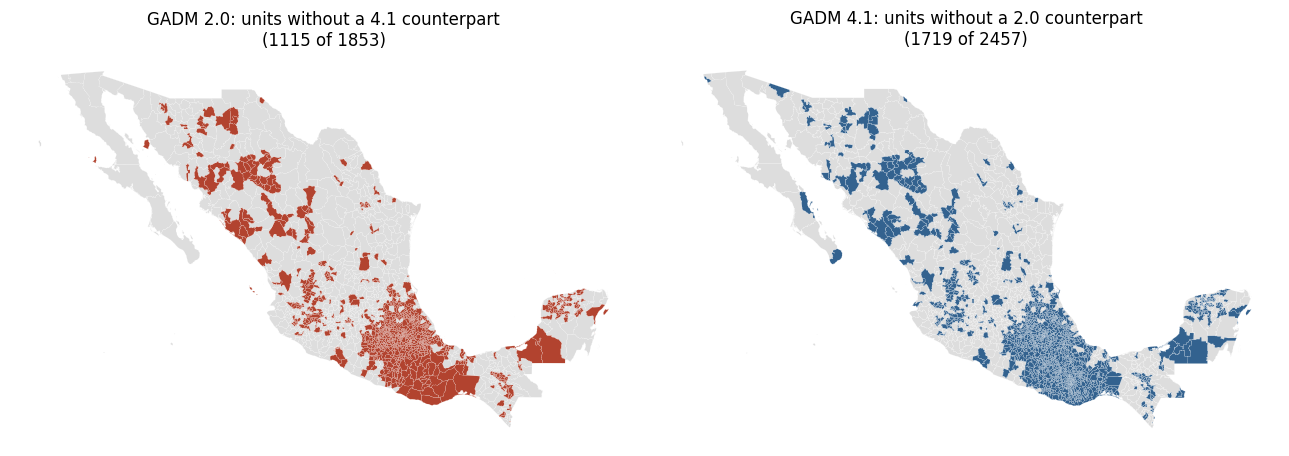

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, shapes, color, title in (
    (axes[0], shapes20, "#b2432f", "GADM 2.0: units without a 4.1 counterpart"),
    (axes[1], shapes41, "#33628f", "GADM 4.1: units without a 2.0 counterpart"),
):
    shapes[shapes["matched"]].plot(ax=ax, color="#dddddd", edgecolor="white", linewidth=0.1)
    shapes[~shapes["matched"]].plot(ax=ax, color=color, edgecolor="white", linewidth=0.1)
    n = (~shapes["matched"]).sum()
    ax.set_title(f"{title}\n({n} of {len(shapes)})")
    ax.set_axis_off()
plt.tight_layout()

## Results on both versions

Each draw is aggregated first, averaged over the window, and the
percentiles are taken across the 99 draws per municipality. The maps
below show the median for 2080 to 2099; the [interactive
version](https://climateimpactlab.github.io/cil_regionalization/mexico_rates.html)
has the other percentiles and windows.

The statistic decides what the map looks like: the median sits
slightly below zero for most municipalities, while the hottest climate
models make the 95th percentile strongly positive. Carleton et al.
(2022) Figure IV shows a climate-model-weighted mean of a different
projection run; these maps are not that figure.

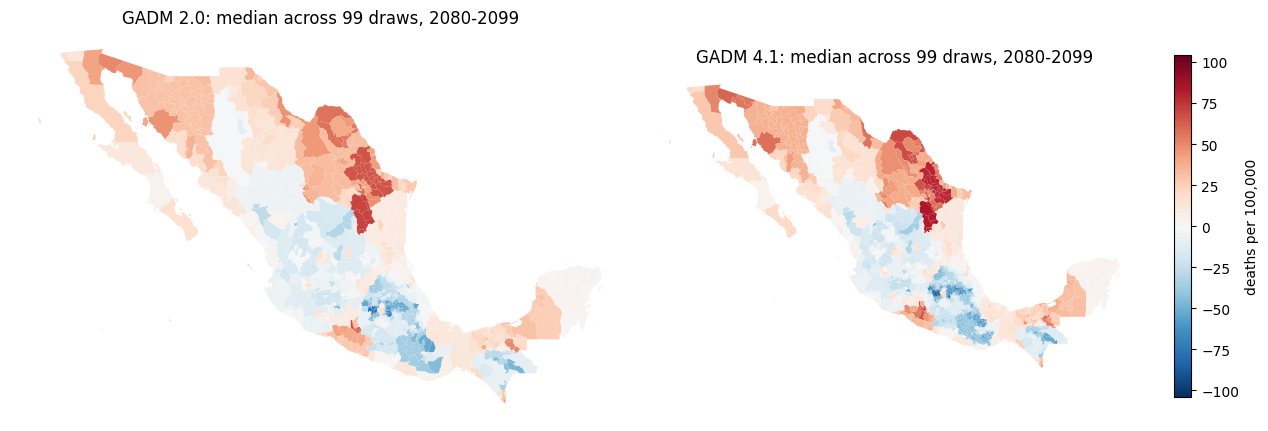

In [6]:
q20 = compute.window_percentiles("2.0")
q41 = compute.window_percentiles("4.1")

def zero_centered(values):
    m = float(np.nanmax(np.abs(values)))
    return TwoSlopeNorm(vmin=-m, vcenter=0.0, vmax=m)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, shapes, q, keys, title in (
    (axes[0], shapes20, q20, ["ISO", "ID_1", "ID_2"], "GADM 2.0"),
    (axes[1], shapes41, q41, ["GID_0", "GID_1", "GID_2"], "GADM 4.1"),
):
    m = shapes.merge(q[q["window"] == "2080-2099"], on=keys)
    m.plot(column="q50", ax=ax, cmap="RdBu_r", norm=zero_centered(m["q50"]),
           legend=(title == "GADM 4.1"),
           legend_kwds={"label": "deaths per 100,000", "shrink": 0.6})
    ax.set_title(f"{title}: median across 99 draws, 2080-2099")
    ax.set_axis_off()
plt.tight_layout()

## Comparing units that exist in both versions

The two versions have different unit universes, so most municipalities
cannot be compared one to one: 1,115 units of GADM 2.0 have no GADM
4.1 counterpart and 1,719 of GADM 4.1 have no 2.0 counterpart. The 738
that are recognizably the same unit can be compared, and the crosswalk
committed next to this notebook lists them. The largest differences
sit where boundaries moved even for units that kept their identity.

In [7]:
cross = pd.read_parquet(compute.DATA / "adm2_crosswalk.parquet")
q20w = q20[q20["window"] == "2080-2099"]
q41w = q41[q41["window"] == "2080-2099"]
cmp = (cross.merge(q20w, on=["ISO", "ID_1", "ID_2"])
       .merge(q41w, on=["GID_0", "GID_1", "GID_2"], suffixes=("_20", "_41")))
cmp["difference"] = cmp["q50_41"] - cmp["q50_20"]
print(f"comparable units: {len(cmp)}; median |difference| in the median rate "
      f"{cmp['difference'].abs().median():.1f} per 100,000")
(cmp.nlargest(8, "difference", keep="all")
 [["NAME_2_41", "NAME_1_41", "q50_20", "q50_41", "difference", "iou"]]
 .rename(columns={"NAME_2_41": "municipality", "NAME_1_41": "state"})
 .round(2))

comparable units: 738; median |difference| in the median rate 0.2 per 100,000


,municipality,state,q50_20,q50_41,difference,iou
214,Arcelia,Guerrero,-23.52,15.41,38.93,0.53
172,Tlahualilo,Durango,-6.81,18.53,25.34,0.58
213,Ajuchitlán del Progreso,Guerrero,47.51,64.29,16.78,0.65
408,Yurécuaro,Michoacán,-26.06,-15.49,10.56,0.72
157,Mapimí,Durango,-6.81,3.34,10.15,0.68
138,San Buenaventura,Coahuila,38.51,48.44,9.93,0.66
723,Monte Escobedo,Zacatecas,-22.13,-13.55,8.59,0.52
361,La Piedad,Michoacán,-26.06,-17.53,8.53,0.61


In [8]:
# The national check: both versions allocate the same Mexican inputs,
# so the totals must match; any difference between a version's
# Mexican-unit sum and the input is border spill, not lost mass.
mex_input = draw[draw["hierid"].str.startswith("MEX") & (draw["year"] == 2099)]["deaths"].sum()
print(f"deaths in Mexican impact regions, 2099:  {mex_input:.6e}")
for name, r, iso in (("2.0", r20, "ISO"), ("4.1", r41, "GID_0")):
    d99 = r[r["year"] == 2099]
    mex_units = d99[d99[iso] == "MEX"]["deaths"].sum()
    spill = mex_units - mex_input
    print(f"GADM {name}: Mexican-unit total {mex_units:.6e} "
          f"(border spill {spill:+.2e}, {abs(spill) / abs(mex_input) * 100:.2f}%)")

deaths in Mexican impact regions, 2099:  -2.179846e+04
GADM 2.0: Mexican-unit total -2.179846e+04 (border spill -3.64e-12, 0.00%)
GADM 4.1: Mexican-unit total -2.175063e+04 (border spill +4.78e+01, 0.22%)
